In [8]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


class UKFPSimulator:

    def __init__(self, n_runs, deanery_data, user_preferences):
        self.n_runs = n_runs
        self.deanery_data = deanery_data.copy()
        self.user_preferences = user_preferences

        if len(self.user_preferences) != len(self.deanery_data):
            raise ValueError(
                "User preferences must contain exactly all foundation"
                " schools."
            )

        self.deanery_data["id"] = np.arange(len(self.deanery_data))
        self.name_to_id = dict(
            zip(
                self.deanery_data["foundation_school"],
                self.deanery_data["id"],
            )
        )

        self.places = self.deanery_data["places"].values
        self.weights = self.deanery_data["ratio"].values

        # Scale raw demand to match total available places 1:1
        raw_demand = self.places * self.weights
        self.total_places = self.places.sum()
        scaling_factor = self.total_places / raw_demand.sum()

        self.first_choice_counts = np.round(
            raw_demand * scaling_factor
        ).astype(int)
        remainder = self.total_places - self.first_choice_counts.sum()
        self.first_choice_counts[np.argmax(self.places)] += remainder

        self.user_prefs_ids = np.array(
            [self.name_to_id[name] for name in self.user_preferences]
        )

    def _generate_synthetic_cohort(self):
        user_first_choice = self.user_prefs_ids[0]
        adjusted_counts = self.first_choice_counts.copy()
        if adjusted_counts[user_first_choice] > 0:
            adjusted_counts[user_first_choice] -= 1

        first_choices = np.repeat(
            np.arange(len(self.places)), adjusted_counts
        )
        n_synthetic = len(first_choices)

        log_weights = np.log(self.weights + 1e-9)
        gumbel_noise = np.random.gumbel(size=(n_synthetic, len(self.places)))
        scores = log_weights + gumbel_noise

        row_indices = np.arange(n_synthetic)
        scores[row_indices, first_choices] = -np.inf

        remaining_choices = np.argsort(-scores, axis=1)[:, :-1]
        return np.column_stack((first_choices, remaining_choices))

    def _run_single_simulation(self):
        synthetic_prefs = self._generate_synthetic_cohort()
        all_prefs = np.vstack([synthetic_prefs, self.user_prefs_ids])
        n_total_students = len(all_prefs)
        user_index = n_total_students - 1

        random_ranks = np.random.rand(n_total_students)
        process_order = np.argsort(random_ranks)

        user_random_rank = np.where(process_order == user_index)[0][0] + 1

        places_left = self.places.copy()
        allocated = np.full(n_total_students, -1)

        # Pass 1
        for i in process_order:
            pref_1 = all_prefs[i, 0]
            if places_left[pref_1] > 0:
                allocated[i] = pref_1
                places_left[pref_1] -= 1

        # Pass 2
        for i in process_order:
            if allocated[i] == -1:
                for j in range(1, len(self.places)):
                    pref_j = all_prefs[i, j]
                    if places_left[pref_j] > 0:
                        allocated[i] = pref_j
                        places_left[pref_j] -= 1
                        break

        user_final_allocation_id = allocated[user_index]
        choice_idx = (
            np.where(self.user_prefs_ids == user_final_allocation_id)[0][0] + 1
        )

        return user_random_rank, choice_idx
    
    def plot_scatter_results(self, alpha=0.5, jitter=0.15):
        """Generates a scatter plot of rank vs choice received with the Y-axis hidden

        and a detailed, color-coded legend matching the bar chart.
        """
        print(
            f"Running {self.n_runs} simulations for scatter plot analysis..."
        )

        sim_results = []
        for _ in range(self.n_runs):
            rank, choice_num = self._run_single_simulation()
            sim_results.append(
                {
                    "user_rank": rank,
                    "choice_num": choice_num,
                }
            )

        df_sim = pd.DataFrame(sim_results)
        counts = df_sim["choice_num"].value_counts()
        unique_choices = sorted(df_sim["choice_num"].unique())

        plt.figure(figsize=(14, 8))

        # Plot each choice as a distinct scatter series to build legend entries automatically
        for choice_num in unique_choices:
            df_sub = df_sim[df_sim["choice_num"] == choice_num]

            # Apply vertical jitter to separate overlapping points into distinct horizontal bands
            y_jittered = df_sub["choice_num"] + np.random.uniform(
                -jitter, jitter, size=len(df_sub)
            )

            school_name = self.user_preferences[choice_num - 1]
            overall_pct = (counts.get(choice_num, 0) / self.n_runs) * 100
            label_text = (
                f"Choice {choice_num}: {school_name} ({overall_pct:.1f}%)"
            )

            plt.scatter(
                df_sub["user_rank"],
                y_jittered,
                alpha=alpha,
                s=30,
                edgecolors="none",
                label=label_text,
            )

        # Completely hide the Y-axis
        plt.gca().get_yaxis().set_visible(False)

        plt.title(
            f"UKFP Simulation: Random Rank Position vs Choice Received ({self.n_runs:,} Runs)",
            fontsize=14,
            pad=15,
        )
        plt.xlabel(
            f"Random Rank Position (1 = Best Rank, {self.total_places:,} = Worst Rank)",
            fontsize=11,
        )
        plt.legend(
            title="Choice Allocated (Overall %)",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.grid(axis="x", linestyle="--", alpha=0.4)
        plt.tight_layout()

        plt.show()

        return df_sim

    def run_full_analysis(self, n_bins=10):
        """Runs simulations, prints all 18 choices to console, and plots the ordered stacked bar chart."""
        print(f"Running {self.n_runs} simulations...")

        sim_results = []
        for _ in range(self.n_runs):
            rank, choice_num = self._run_single_simulation()
            sim_results.append(
                {
                    "user_rank": rank,
                    "choice_num": choice_num,
                }
            )

        df_sim = pd.DataFrame(sim_results)

        # --- 1. CONSOLE OUTPUT (ALL 18 PLACES) ---
        counts = df_sim["choice_num"].value_counts()

        summary_data = []
        for pref_idx in range(1, len(self.user_preferences) + 1):
            school_name = self.user_preferences[pref_idx - 1]
            count = counts.get(pref_idx, 0)
            percentage = (count / self.n_runs) * 100
            summary_data.append(
                {
                    "Preference #": f"Choice {pref_idx}",
                    "Foundation School": school_name,
                    "Overall Probability (%)": f"{percentage:.2f}%",
                    "_raw_pct": percentage,
                }
            )

        df_console = pd.DataFrame(summary_data)

        print("\n" + "=" * 60)
        print("         SIMULATION RESULTS: ALL 18 PREFERENCES")
        print("=" * 60)
        print(
            df_console[
                [
                    "Preference #",
                    "Foundation School",
                    "Overall Probability (%)",
                ]
            ].to_string(index=False)
        )
        print("=" * 60 + "\n")

        # --- 2. GRAPH SETUP WITH NUMERIC ORDERING ---
        df_sim["rank_percentile"] = (
            df_sim["user_rank"] / self.total_places
        ) * 100

        bin_edges = np.linspace(0, 100, n_bins + 1)
        bin_labels = [
            f"{int(bin_edges[i])}–{int(bin_edges[i+1])}%"
            for i in range(n_bins)
        ]

        df_sim["rank_bracket"] = pd.cut(
            df_sim["rank_percentile"],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True,
        )

        # Pivot by choice_num to guarantee strict numerical sorting (1, 2, 3...)
        pivot_df = (
            df_sim.groupby(["rank_bracket", "choice_num"], observed=False)
            .size()
            .unstack(fill_value=0)
        )

        # Ensure all choices that appeared are sorted numerically
        pivot_df = pivot_df.reindex(columns=sorted(pivot_df.columns))

        # Convert to percentage per rank bracket
        pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

        # Build legend labels showing Choice #, School Name, and Overall %
        legend_labels = []
        for choice_num in pivot_df.columns:
            school_name = self.user_preferences[choice_num - 1]
            overall_pct = (
                df_sim["choice_num"].value_counts().get(choice_num, 0)
                / self.n_runs
            ) * 100
            legend_labels.append(
                f"Choice {choice_num}: {school_name} ({overall_pct:.1f}%)"
            )

        # Plot
        plt.figure(figsize=(14, 8))
        ax = pivot_pct.plot(
            kind="bar", stacked=True, colormap="tab20", figsize=(14, 8)
        )

        plt.title(
            f"UKFP Allocation Choice by Random Rank Position ({self.n_runs:,} Runs)",
            fontsize=14,
            pad=15,
        )
        plt.xlabel(
            "Random Rank Percentile Bracket (0–10% = Top Ranks)",
            fontsize=11,
        )
        plt.ylabel("Percentage of Runs (%)", fontsize=11)
        plt.legend(
            legend_labels,
            title="Choice Allocated (Overall %)",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.xticks(rotation=0)
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()

        plt.show()

        return df_console

Running 1000 simulations...

         SIMULATION RESULTS: ALL 18 PREFERENCES
Preference #     Foundation School Overall Probability (%)
    Choice 1                London                  46.30%
    Choice 2      Northern Ireland                  30.30%
    Choice 3                   KSS                   4.10%
    Choice 4                Wessex                  14.50%
    Choice 5  Yorkshire and Humber                   0.10%
    Choice 6                 Wales                   0.00%
    Choice 7              Northern                   0.00%
    Choice 8       East of England                   2.80%
    Choice 9             Peninsula                   0.00%
   Choice 10              Scotland                   0.00%
   Choice 11                Severn                   0.00%
   Choice 12 North West of England                   0.00%
   Choice 13  Thames Valley Oxford                   0.00%
   Choice 14 West Midlands Central                   0.00%
   Choice 15   West Midlands North    

<Figure size 1400x800 with 0 Axes>

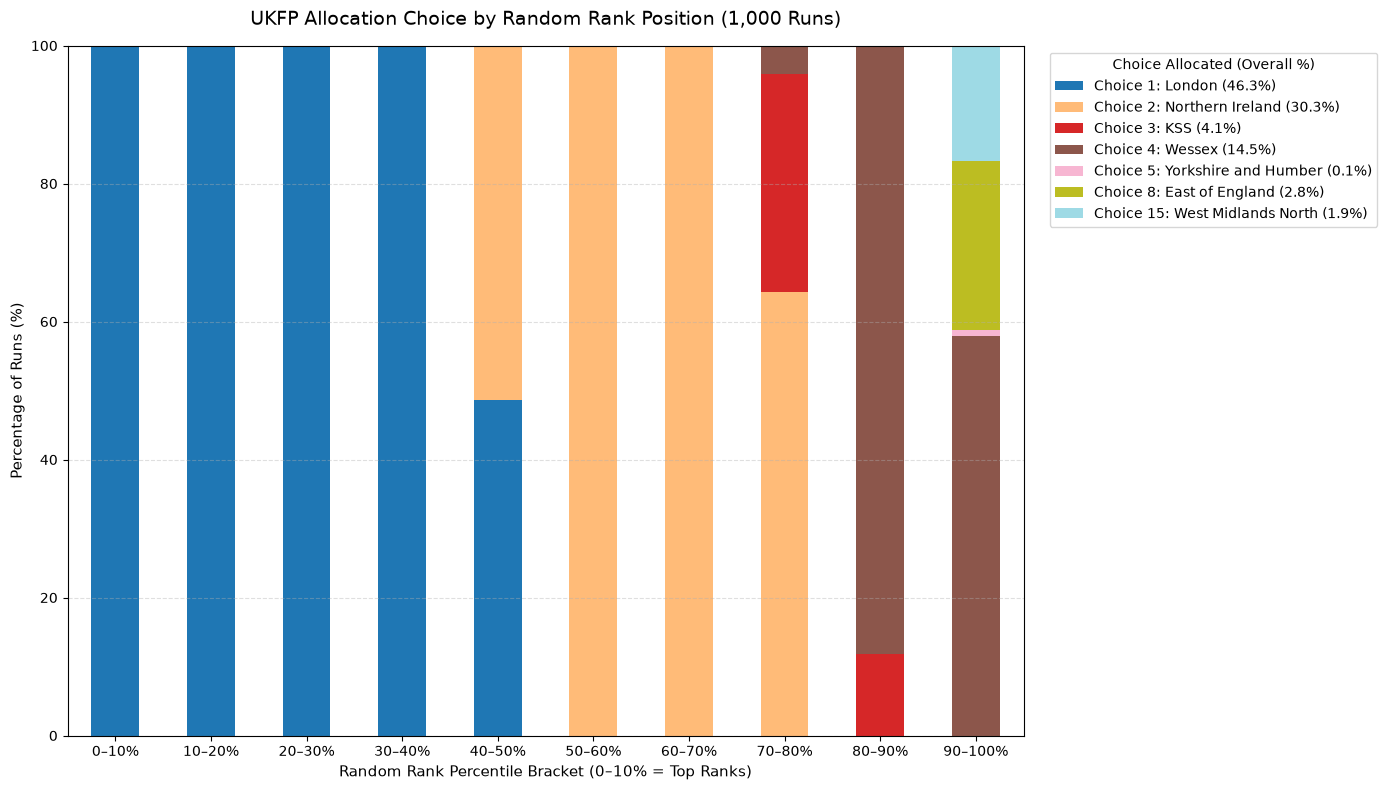

In [9]:
# The 2026 data from your table
data_2026 = pd.DataFrame([
    {"foundation_school": "East of England", "places": 921, "ratio": 0.69},
    {"foundation_school": "KSS", "places": 703, "ratio": 0.84},
    {"foundation_school": "LNR", "places": 330, "ratio": 0.74},
    {"foundation_school": "London", "places": 1216, "ratio": 2.31},
    {"foundation_school": "North West of England", "places": 1081, "ratio": 1.16},
    {"foundation_school": "Northern", "places": 568, "ratio": 0.74},
    {"foundation_school": "Northern Ireland", "places": 387, "ratio": 0.78},
    {"foundation_school": "Peninsula", "places": 319, "ratio": 0.87},
    {"foundation_school": "Scotland", "places": 1237, "ratio": 1.09},
    {"foundation_school": "Severn", "places": 421, "ratio": 1.33},
    {"foundation_school": "Thames Valley Oxford", "places": 342, "ratio": 1.30},
    {"foundation_school": "Trent", "places": 474, "ratio": 0.51},
    {"foundation_school": "Wales", "places": 460, "ratio": 0.65},
    {"foundation_school": "Wessex", "places": 437, "ratio": 0.58},
    {"foundation_school": "West Midlands Central", "places": 286, "ratio": 1.51},
    {"foundation_school": "West Midlands North", "places": 436, "ratio": 0.39},
    {"foundation_school": "West Midlands South", "places": 294, "ratio": 0.50},
    {"foundation_school": "Yorkshire and Humber", "places": 898, "ratio": 0.76}
])

# YOUR PERSONAL PREFERENCE LIST (1st to 18th)
# Ensure spelling matches the 'foundation_school' column exactly
my_ranking = [
    "London", 
    "Northern Ireland",
    "KSS", 
    "Wessex",
    "Yorkshire and Humber",
    "Wales",
    "Northern",
    "East of England",
    "Peninsula",
    "Scotland",
    "Severn",
    "North West of England",
    "Thames Valley Oxford", 
    "West Midlands Central",
    "West Midlands North",
    "West Midlands South",
    "LNR",
    "Trent",
]

# Run simulations and generate both outputs
simulator = UKFPSimulator(
    n_runs=1000, deanery_data=data_2026, user_preferences=my_ranking
)
results_df = simulator.run_full_analysis(n_bins=10)

Running 1000 simulations for scatter plot analysis...


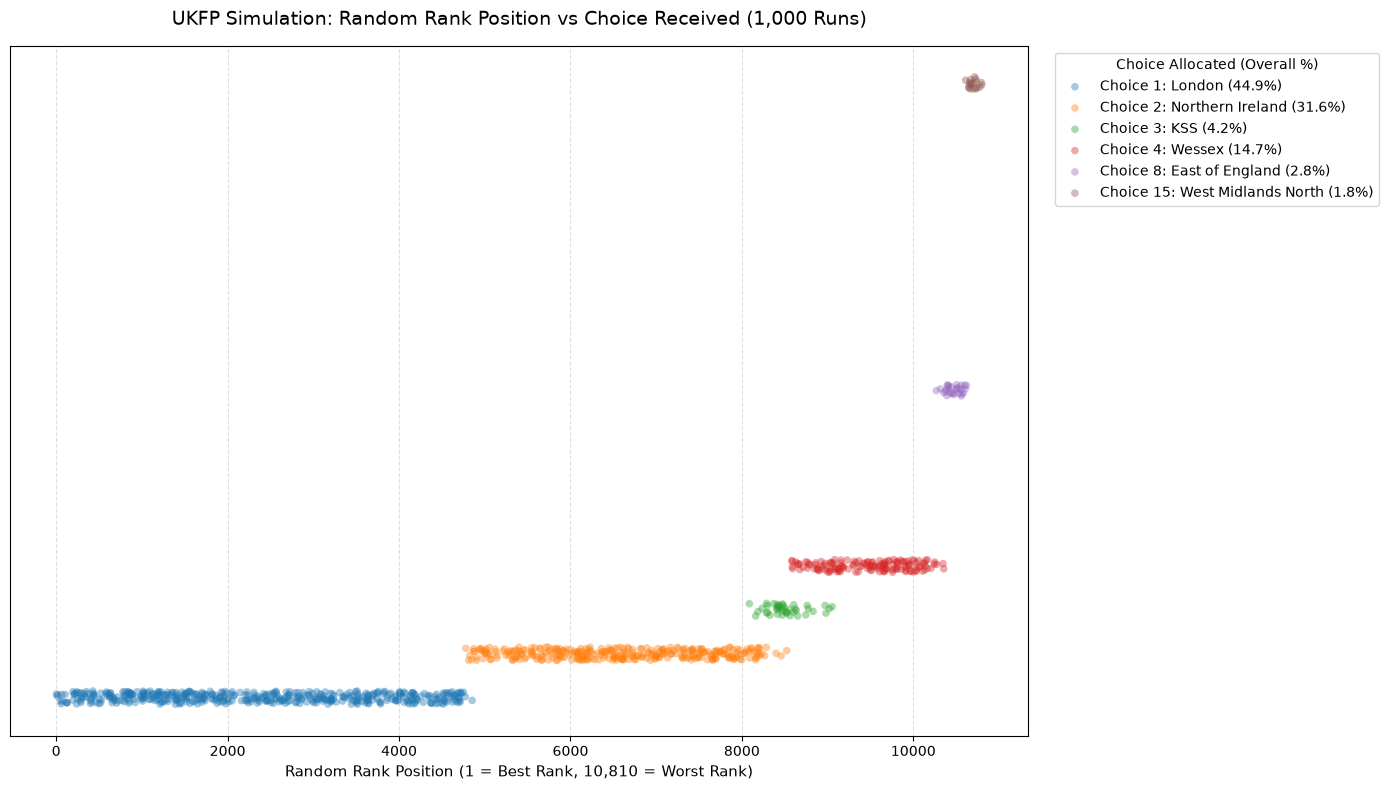

In [10]:
df_scatter = simulator.plot_scatter_results(alpha=0.4, jitter=0.15)